Stage 2: Create blk 864 floor layout JSON

- Create blk864.json using the unit templates in unittemplates_rm_mirrors.json.

- Start by duplicating 4r_corr four times and place the copies side by side with no gaps. Label them from left to right as 450, 452, 454, and 456.

- For the left-side pair, place 4r_corr_end_mirror_x on the left and 5r_corr_end_mirror_x on the right. Align them so both have the same minimum y-coordinate, then join them directly. Any corridor facade that lies along their shared wall must be removed because that section is now an internal interface. Rotate the joined pair 90° clockwise, then label the 4-room unit as 446 and the 5-room unit as 448. Move the pair to the left of the central row so that the horizontal gap between 446 and 450 is exactly 4 m. Also align the pair vertically so its maximum y-coordinate is the same as the maximum y-coordinate of the central row.

- For the right-side pair, duplicate the already transformed 446–448 pair and mirror the duplicate about the origin using (x, y) → (-x, -y). Rename the mirrored 5-room unit as 458 and the mirrored 4-room unit as 460. Move this pair to the right of the central row so that the horizontal gap between 456 and 460 is exactly 4 m. Position it vertically so that the minimum y-coordinate of the right pair is 2 m lower than the minimum y-coordinate of the central row.

- Every transformation applied to a unit must also be applied to its facade geometry. This includes all room coordinates, facade start, facade end, and facade points, so windows and corridor walls remain attached to the correct locations after moving, rotating, or mirroring.

- After all eight units are positioned, combine them into one block and translate the entire block together so the overall minimum x- and y-coordinates are convenient, typically zero. Do not normalise individual units after final positioning because this would change the required gaps and alignments.

- Save the final result as blk864.json in compact format and include: "numberStories": 12

- Final checks:
450.min_x - 446.max_x = 4 m
460.min_x - 456.max_x = 4 m
max_y(446, 448) = max_y(450, 452, 454, 456)
min_y(458, 460) = min_y(450, 452, 454, 456) - 2 m
Corridor facades are removed along all shared unit interfaces (between side 4 rooms and 5 rooms, between all 4 rooms central row)

In [1]:
import json
from copy import deepcopy
from pathlib import Path


INPUT_JSON = Path(r"C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines JSON\unittemplates_rm_mirrors.json")
OUTPUT_JSON = Path(r"C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines JSON\blk864.json")

GAP = 4
NUMBER_STORIES = 12
TOL = 1e-6


def edit(unit, fn):
    unit = deepcopy(unit)

    for room in unit["rooms"].values():
        room["coordinates"] = [list(fn(x, y)) for x, y in room["coordinates"]]

    for facade in unit.get("facades", []):
        for key in ("start", "end"):
            if key in facade:
                facade[key] = list(fn(*facade[key]))

        if "points" in facade:
            facade["points"] = [list(fn(*p)) for p in facade["points"]]

    return unit


def bounds(unit):
    pts = [p for room in unit["rooms"].values() for p in room["coordinates"]]
    xs, ys = zip(*pts)
    return min(xs), max(xs), min(ys), max(ys)


def move(unit, dx=0, dy=0):
    return edit(unit, lambda x, y: (x + dx, y + dy))


def rotate_cw(unit):
    return edit(unit, lambda x, y: (y, -x))


def mirror_origin(unit):
    return edit(unit, lambda x, y: (-x, -y))


def normalise(units):
    min_x = min(bounds(u)[0] for u in units.values())
    min_y = min(bounds(u)[2] for u in units.values())

    return {
        n: move(u, -min_x, -min_y)
        for n, u in units.items()
    }


def join(left, right):
    left = move(left, -bounds(left)[0], -bounds(left)[2])

    right = move(
        right,
        bounds(left)[1] - bounds(right)[0],
        -bounds(right)[2]
    )

    return left, right


def remove_interface_corridor(unit, interface_x, y_min, y_max):
    new_facades = []

    for facade in unit.get("facades", []):

        if facade.get("type", "").lower() != "corridor":
            new_facades.append(facade)
            continue

        points = facade["points"]

        for p1, p2 in zip(points[:-1], points[1:]):
            x1, y1 = p1
            x2, y2 = p2

            # Only modify vertical corridor segments on the interface.
            if (
                abs(x1 - interface_x) < TOL
                and abs(x2 - interface_x) < TOL
            ):
                low = min(y1, y2)
                high = max(y1, y2)

                overlap_low = max(low, y_min)
                overlap_high = min(high, y_max)

                # No shared overlap.
                if overlap_high <= overlap_low:
                    new_facade = deepcopy(facade)
                    new_facade["points"] = [p1, p2]
                    new_facades.append(new_facade)
                    continue

                # Keep exposed portion below interface.
                if low < overlap_low:
                    segment = [
                        [interface_x, low],
                        [interface_x, overlap_low]
                    ]

                    if y1 > y2:
                        segment.reverse()

                    new_facade = deepcopy(facade)
                    new_facade["points"] = segment
                    new_facades.append(new_facade)

                # Keep exposed portion above interface.
                if high > overlap_high:
                    segment = [
                        [interface_x, overlap_high],
                        [interface_x, high]
                    ]

                    if y1 > y2:
                        segment.reverse()

                    new_facade = deepcopy(facade)
                    new_facade["points"] = segment
                    new_facades.append(new_facade)

            else:
                new_facade = deepcopy(facade)
                new_facade["points"] = [p1, p2]
                new_facades.append(new_facade)

    unit["facades"] = new_facades
    return unit


def remove_shared_interface(left, right):
    interface_x = bounds(left)[1]

    y_min = max(
        bounds(left)[2],
        bounds(right)[2]
    )

    y_max = min(
        bounds(left)[3],
        bounds(right)[3]
    )

    length = max(0, y_max - y_min)

    left = remove_interface_corridor(
        left,
        interface_x,
        y_min,
        y_max
    )

    right = remove_interface_corridor(
        right,
        interface_x,
        y_min,
        y_max
    )

    return left, right, length


def tidy_polygon(points):
    points = [list(p) for p in points]

    area = sum(
        x1 * y2 - x2 * y1
        for (x1, y1), (x2, y2)
        in zip(points, points[1:] + points[:1])
    )

    if area < 0:
        points.reverse()

    start = max(
        range(len(points)),
        key=lambda i: (points[i][1], points[i][0])
    )

    points = points[start:] + points[:start]

    return [[round(x, 3), round(y, 3)] for x, y in points]


def tidy_unit(unit):
    for room in unit["rooms"].values():
        room["coordinates"] = tidy_polygon(room["coordinates"])

    for facade in unit.get("facades", []):
        for key in ("start", "end"):
            if key in facade:
                facade[key] = [round(v, 3) for v in facade[key]]

        if "points" in facade:
            facade["points"] = [
                [round(x, 3), round(y, 3)]
                for x, y in facade["points"]
            ]

    return unit


def build_block(templates):

    # ========================================================
    # 450, 452, 454, 456
    # ========================================================

    base = deepcopy(templates["4r_corr"])
    base = move(base, -bounds(base)[0], -bounds(base)[2])

    width = bounds(base)[1] - bounds(base)[0]

    middle = {
        number: move(base, i * width, 0)
        for i, number in enumerate(
            ["450", "452", "454", "456"]
        )
    }

    # Remove corridor facade along central shared interfaces.
    central_interfaces = {}

    for left_num, right_num in [
        ("450", "452"),
        ("452", "454"),
        ("454", "456"),
    ]:
        middle[left_num], middle[right_num], length = remove_shared_interface(
            middle[left_num],
            middle[right_num]
        )

        central_interfaces[f"{left_num}-{right_num}"] = length

    middle_min_y = min(
        bounds(u)[2]
        for u in middle.values()
    )

    middle_max_y = max(
        bounds(u)[3]
        for u in middle.values()
    )


    # ========================================================
    # 446 + 448
    # ========================================================

    u446 = deepcopy(
        templates["4r_corr_end_mirror_x"]
    )

    u448 = deepcopy(
        templates["5r_corr_end_mirror_x"]
    )

    u446, u448 = join(u446, u448)

    # Remove corridor facade from the exact shared interface.
    u446, u448, side_interface_length = remove_shared_interface(
        u446,
        u448
    )

    print(
        f"446-448 interface before rotation: "
        f"{side_interface_length:.3f} m"
    )


    # Rotate pair 90 degrees clockwise.
    left_pair = {
        "446": rotate_cw(u446),
        "448": rotate_cw(u448),
    }

    left_pair = normalise(left_pair)


    # ========================================================
    # Position left pair
    # 4 m specifically between 446 and 450
    # ========================================================

    dx = (
        bounds(middle["450"])[0]
        - GAP
        - bounds(left_pair["446"])[1]
    )

    left_max_y = max(
        bounds(u)[3]
        for u in left_pair.values()
    )

    dy = middle_max_y - left_max_y

    left_pair = {
        n: move(u, dx, dy)
        for n, u in left_pair.items()
    }


    # ========================================================
    # 458 + 460
    # Mirror completed left pair
    # ========================================================

    right_pair = {
        "458": mirror_origin(
            deepcopy(left_pair["448"])
        ),
        "460": mirror_origin(
            deepcopy(left_pair["446"])
        ),
    }


    # ========================================================
    # Position right pair
    # 4 m specifically between 456 and 460
    # ========================================================

    dx = (
        bounds(middle["456"])[1]
        + GAP
        - bounds(right_pair["460"])[0]
    )

    right_min_y = min(
        bounds(u)[2]
        for u in right_pair.values()
    )

    dy = (
        middle_min_y
        - 2
        - right_min_y
    )

    right_pair = {
        n: move(u, dx, dy)
        for n, u in right_pair.items()
    }


    # ========================================================
    # Combine complete block
    # ========================================================

    units = {
        "446": left_pair["446"],
        "448": left_pair["448"],
        "450": middle["450"],
        "452": middle["452"],
        "454": middle["454"],
        "456": middle["456"],
        "458": right_pair["458"],
        "460": right_pair["460"],
    }

    units = normalise(units)

    units = {
        n: tidy_unit(u)
        for n, u in units.items()
    }

    return units, side_interface_length, central_interfaces


def save_compact_json(units, output_path):
    lines = ["{"]

    for number, unit in units.items():

        lines.append(f'    "{number}": {{')
        lines.append('        "rooms": {')

        rooms = list(unit["rooms"].items())

        for i, (name, room) in enumerate(rooms):
            comma = "," if i < len(rooms) - 1 else ""

            lines.append(
                f'            "{name}": '
                f'{json.dumps(room, separators=(",", ":"))}{comma}'
            )

        lines.append("        },")

        facades = json.dumps(
            unit.get("facades", []),
            separators=(",", ":")
        )

        lines.append(
            f'        "facades": {facades}'
        )

        lines.append("    },")

    lines.append(
        f'    "numberStories": {NUMBER_STORIES}'
    )

    lines.append("}")

    output_path.write_text(
        "\n".join(lines),
        encoding="utf-8"
    )


with INPUT_JSON.open(encoding="utf-8") as f:
    templates = json.load(f)


units, side_interface_length, central_interfaces = build_block(
    templates
)

save_compact_json(
    units,
    OUTPUT_JSON
)


# ============================================================
# CHECKS
# ============================================================

left_gap = (
    bounds(units["450"])[0]
    - bounds(units["446"])[1]
)

right_gap = (
    bounds(units["460"])[0]
    - bounds(units["456"])[1]
)

middle_max_y = max(
    bounds(units[n])[3]
    for n in ["450", "452", "454", "456"]
)

left_max_y = max(
    bounds(units[n])[3]
    for n in ["446", "448"]
)

middle_min_y = min(
    bounds(units[n])[2]
    for n in ["450", "452", "454", "456"]
)

right_min_y = min(
    bounds(units[n])[2]
    for n in ["458", "460"]
)


print(f"\nSaved: {OUTPUT_JSON}")

print("\nInternal interfaces:")
print(f"446-448: {side_interface_length:.3f} m")
print(f"458-460: {side_interface_length:.3f} m")

for name, length in central_interfaces.items():
    print(f"{name}: {length:.3f} m")

print("\nPosition checks:")
print(f"446 to 450 gap: {left_gap:.3f} m")
print(f"456 to 460 gap: {right_gap:.3f} m")

print(
    f"Left pair max y: {left_max_y:.3f} m | "
    f"Middle max y: {middle_max_y:.3f} m"
)

print(
    f"Right pair min y: {right_min_y:.3f} m | "
    f"Expected: {middle_min_y - 2:.3f} m"
)

446-448 interface before rotation: 8.100 m

Saved: C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines JSON\blk864.json

Internal interfaces:
446-448: 8.100 m
458-460: 8.100 m
450-452: 10.200 m
452-454: 10.200 m
454-456: 10.200 m

Position checks:
446 to 450 gap: 4.000 m
456 to 460 gap: 4.000 m
Left pair max y: 24.150 m | Middle max y: 24.150 m
Right pair min y: 11.950 m | Expected: 11.950 m


(beta single story) 
- Single floor but with elevation
- Void deck to lvl 2: 3.6m
- Between levels onwards: 2.8m
- Convert into IDF but no multiple stories (ignores numberStories)
- Generates base blk 864 template

Checks
- 32 zones for lower
- 48 zones for upper
- 18 windows upper, 24 windows upper
- 32 AC zones (8 x 4)

IDF saved to: C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\blk_864_base.idf


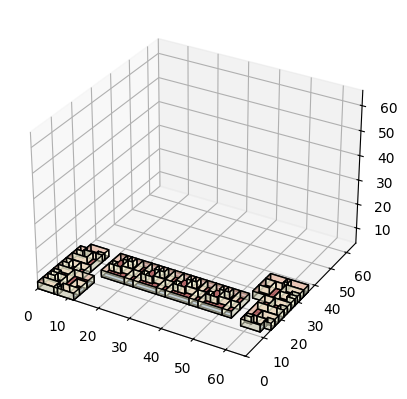

In [1]:
"""Convert a block-floorplan JSON into a Stage-3 EnergyPlus IDF.

Designed for EnergyPlus 9.1 + geomeppy and based on the geometry workflow used
in OneBlock.ipynb.

Final modelling assumptions
---------------------------
* Every room polygon is an EnergyPlus Zone.
* Only masterroom/bedroom/living-room zones receive Ideal Loads HVAC.
* Thermostat: 20 C heating / 25 C cooling.
* No heating, so utilise Always Off schedule
* Humidity control: 30% RH minimum / 60% RH maximum. But no humidifier.
* Bedrooms/masterrooms: 0.2 ACH infiltration.
* Living rooms: 0.2 ACH while AC is on, 1.0 ACH while AC is off.
* Other rooms: 1.0 ACH infiltration.
* Floor: Adiabatic, NoSun, NoWind.
* Ceiling/top roof: Adiabatic, NoSun, NoWind.
* Ordinary exterior walls: Outdoors, SunExposed, WindExposed.
* JSON facades only labelled window: Outdoors, Sun, WindExposed.
* JSON facades only labelled corridor: Outdoors, NoSun, WindExposed
* JSON facades labelled with both window and corridor: Outdoors, NoSun, WindExposed
* Windows are created ONLY on JSON facades labelled window.
"""
import json
import math
import re

from geomeppy import IDF

# --- SETTINGS ---
BASE_ELEVATION, FLOOR_HEIGHT = 3.6, 2.8
WALL_CONST, FLOOR_CONST, ROOF_CONST = "Project Wall", "Project Floor", "Project Flat Roof"
CEIL_CONST, WIN_CONST = "Project Ceiling", "Project External Window"
ALWAYS_ON, ALWAYS_OFF, AC_NORMAL, AC_24HR = "Always On", "Always Off", "AirCon_normal", "AirCon_24hr"
AC_SCHEDULE, THERMOSTAT_NAME, LIVING_INFIL_SCHED = AC_NORMAL, "Zone Stat", "Living_Infiltration_AirCon"
HEATING_SP, COOLING_SP, MAX_RH, TOL = 20.0, 25.0, 60.0, 1e-5

# --- HELPERS & GEOMETRY ---
def get_obj(idf, obj_type, name):
    return next((o for o in idf.idfobjects[obj_type.upper()] if str(o.Name).strip().lower() == name.lower()), None)

def room_type(name):
    n = name.lower()
    return "masterroom" if ("masterroom" in n or "master_room" in n) else "bedroom" if "bedroom" in n else "living" if "living" in n else "other"

def pt_dist(p, s, e):
    dx, dy = e[0] - s[0], e[1] - s[1]
    return abs((p[0] - s[0]) * dy - (p[1] - s[1]) * dx) / math.hypot(dx, dy) if math.hypot(dx, dy) > TOL else float("inf")

def segments_overlap(a1, a2, b1, b2):
    if pt_dist(b1, a1, a2) > TOL or pt_dist(b2, a1, a2) > TOL: return False
    dx, dy = a2[0] - a1[0], a2[1] - a1[1]
    L2 = dx*dx + dy*dy
    if L2 <= TOL**2: return False
    t1, t2 = [(p[0]-a1[0])*dx + (p[1]-a1[1])*dy / L2 for p in (b1, b2)]
    return max(0.0, min(t1, t2)) < min(1.0, max(t1, t2)) - TOL

def find_facade_walls(idf, start, end):
    matched = []
    for w in idf.getsurfaces("wall"):
        c = [(float(getattr(v, 'x', v[0])), float(getattr(v, 'y', v[1])), float(getattr(v, 'z', v[2]))) for v in w.coords]
        min_z = min(p[2] for p in c)
        bot = [p[:2] for p in c if abs(p[2] - min_z) <= TOL]
        if len(bot) >= 2 and segments_overlap(bot[0], bot[1], tuple(start[:2]), tuple(end[:2])):
            matched.append(w)
    return matched

def get_segments(facade):
    if "start" in facade and "end" in facade: yield facade["start"], facade["end"]
    else:
        pts = facade.get("points", [])
        for s, e in zip(pts[:-1], pts[1:]): yield s, e

# --- CORE CONVERSION STEPS ---
def create_block(idf, data):
    for uid, udata in data.items():
        if uid == "numberStories" or not isinstance(udata, dict): continue
        for rname, rdata in udata.get("rooms", {}).items():
            if rname.lower() in {"wholeunit", "roomscombined"}: continue
            idf.add_block(name=f"Unit {uid}_{rname}", 
                          coordinates=[(float(x), float(y)) for x, y in rdata["coordinates"]], 
                          height=FLOOR_HEIGHT, num_stories=1)

    for s in idf.idfobjects["BUILDINGSURFACE:DETAILED"]:
        for f in [k for k in s.objls if re.fullmatch(r"Vertex_\d+_Zcoordinate", k) and s[k] not in (None, "")]:
            s[f] = float(s[f]) + BASE_ELEVATION

    idf.intersect_match()
    for w in idf.getsurfaces("wall"): w.Construction_Name = WALL_CONST
    for s in idf.getsurfaces("floor") + idf.getsurfaces("ceiling") + idf.getsurfaces("roof"):
        is_floor = s.Surface_Type.lower() == "floor"
        s.Outside_Boundary_Condition, s.Sun_Exposure, s.Wind_Exposure = "Adiabatic", "NoSun", "NoWind"
        s.Construction_Name = FLOOR_CONST if is_floor else CEIL_CONST

def assign_facade_and_windows(idf, data):
    for w in idf.getsurfaces("wall"):
        if w.Outside_Boundary_Condition.lower() == "outdoors":
            w.Sun_Exposure, w.Wind_Exposure, w.Construction_Name = "SunExposed", "WindExposed", WALL_CONST

    wall_wwr = {}
    for uid, udata in ((k, v) for k, v in data.items() if k != "numberStories" and isinstance(v, dict)):
        for fac in udata.get("facades", []):
            ftypes = {str(fac.get("type", "")).lower()} if not isinstance(fac.get("type"), (list, tuple, set)) else {str(x).lower() for x in fac["type"]}
            is_corr = any("corridor" in t for t in ftypes)
            is_win = any("window" in t for t in ftypes)
            
            for s, e in get_segments(fac):
                for w in [w for w in find_facade_walls(idf, s, e) if w.Outside_Boundary_Condition.lower() == "outdoors"]:
                    if is_corr: w.Sun_Exposure, w.Wind_Exposure = "NoSun", "WindExposed"
                    if is_win: wall_wwr[w.Name] = float(fac.get("WWR", 0.4))

    all_out = [w for w in idf.getsurfaces("wall") if w.Outside_Boundary_Condition.lower() == "outdoors"]
    for wwr in set(wall_wwr.values()):
        targets = {name for name, val in wall_wwr.items() if val == wwr}
        saved = {w.Name: w.Outside_Boundary_Condition for w in all_out}
        for w in all_out:
            if w.Name not in targets: w.Outside_Boundary_Condition = "Adiabatic"
        idf.set_wwr(wwr=wwr, construction=WIN_CONST, force=False)
        for w in all_out: w.Outside_Boundary_Condition = saved[w.Name]

def assign_hvac_and_infil(idf, ac_sched):
    if not get_obj(idf, "HVACTEMPLATE:THERMOSTAT", THERMOSTAT_NAME):
        idf.newidfobject("HVACTEMPLATE:THERMOSTAT", 
                         Name=THERMOSTAT_NAME, 
                         Constant_Heating_Setpoint=HEATING_SP, 
                         Constant_Cooling_Setpoint=COOLING_SP)

    old_sch = get_obj(idf, "SCHEDULE:COMPACT", LIVING_INFIL_SCHED)
    if old_sch: idf.removeidfobject(old_sch)

    sch_fields = {"Field_1": "Through: 12/31", "Field_2": "For: AllDays"}
    if ac_sched == AC_NORMAL:
        sch_fields.update({"Field_3": "Until: 07:00", "Field_4": 0.2, "Field_5": "Until: 22:00", "Field_6": 1.0, "Field_7": "Until: 24:00", "Field_8": 0.2})
    else:
        sch_fields.update({"Field_3": "Until: 24:00", "Field_4": 0.2})
    idf.newidfobject("SCHEDULE:COMPACT", Name=LIVING_INFIL_SCHED, Schedule_Type_Limits_Name="Fraction", **sch_fields)

    for zone in idf.idfobjects["ZONE"]:
        rtype = room_type(zone.Name)
        if rtype in {"masterroom", "bedroom", "living"}:
            idf.newidfobject("HVACTEMPLATE:ZONE:IDEALLOADSAIRSYSTEM", 
                             Zone_Name=zone.Name, 
                             Template_Thermostat_Name=THERMOSTAT_NAME,
                             System_Availability_Schedule_Name=ac_sched, 
                             Cooling_Availability_Schedule_Name=ac_sched,
                             Heating_Availability_Schedule_Name=ALWAYS_OFF, 
                             Heating_Limit="NoLimit", Cooling_Limit="NoLimit",
                             Dehumidification_Control_Type="Humidistat", 
                             Dehumidification_Setpoint=MAX_RH, 
                             Humidification_Control_Type="None", 
                             Outdoor_Air_Method="None")
            
        ach, sched = (0.2, ALWAYS_ON) if rtype in {"masterroom", "bedroom"} else (1.0, LIVING_INFIL_SCHED) if rtype == "living" else (1.0, ALWAYS_ON)
        idf.newidfobject("ZONEINFILTRATION:DESIGNFLOWRATE", 
                         Name=f"{zone.Name} Infiltration", 
                         Zone_or_ZoneList_Name=zone.Name,
                         Schedule_Name=sched, 
                         Design_Flow_Rate_Calculation_Method="AirChanges/Hour", 
                         Air_Changes_per_Hour=ach, 
                         Constant_Term_Coefficient=1.0)

# --- MAIN CONVERTER ---
def convert_json_to_idf(idd_path, template_path, json_path, output_path, ac_schedule=AC_NORMAL, view_model=False):
    IDF.setiddname(idd_path)
    idf = IDF(template_path)
    if not get_obj(idf, "MATERIAL", "ConcreteWall"):
        idf.newidfobject("MATERIAL", 
                         Name="ConcreteWall", 
                         Roughness="MediumRough", 
                         Thickness=0.2, 
                         Conductivity=1.4, 
                         Density=2300.0, 
                         Specific_Heat=880.0, 
                         Thermal_Absorptance=0.9, 
                         Solar_Absorptance=0.65, 
                         Visible_Absorptance=0.65)

    with open(json_path, "r", encoding="utf-8") as f: data = json.load(f)
    create_block(idf, data)
    assign_facade_and_windows(idf, data)
    assign_hvac_and_infil(idf, ac_schedule)
    idf.save(output_path, lineendings="default", encoding="latin-1")
    print(f"IDF saved to: {output_path}")
    if view_model: idf.view_model()
    return idf

if __name__ == "__main__":
    convert_json_to_idf(
        idd_path=r"C:\Users\Heng_\OneDrive\Desktop\Apps\EnergyPlusV9-1-0\Energy+.idd",
        template_path=r"C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\idf_template_SL.idf",
        json_path=r"C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines JSON\blk864.json",
        output_path=r"C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\blk_864_base.idf",
        ac_schedule=AC_SCHEDULE,
        view_model=True,
    )

Stage 4:
- Generate multistory by reading blk864.json and numberStories, and add required elevation to act as (and replace) a void deck 
- Evevation requirements: void deck to lvl 2: 3.6m, Void deck from lvl 2 to 3 onwards: 2.8m 
- Generate 2 files, one idf with suffix _normal 2200-0700 AC first, followed by editing relevant fields of the generated normal AC with 24hr AC (remeber to change not just HVAC settings but also living room infiltration to 0.2 always on) with the suffix _24hAC. Dont generate 2 idf from scratch
- Thermostat setpoint 25 and dehumidification 60 but NO humidification
- Save both under "C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines_idf\blk864"

Checks
- 858 zones (6 x 8 + 2 x 9) x 13
- 520 windows
- 416 AC zones (8 x 4) x 13 


Generating geometry and normal-hours model: blk864_normal.idf
Generating 12 residential storeys
Level 2 floor elevation: 3.6 m
Residential floor-to-floor height: 2.8 m
IDF saved to: c:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\blk864_normal.idf


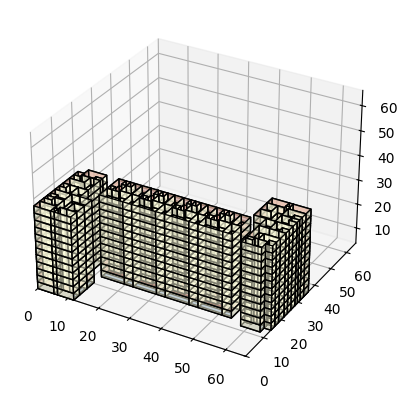


Editing normal-hours IDF into 24-hour copy: blk864_24hAC.idf
24-hour IDF saved to: c:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\blk864_24hAC.idf

Created both Stage-4 IDFs:
c:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\blk864_normal.idf
c:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\blk864_24hAC.idf


In [1]:
"""Convert blk864.json into two Stage-4 multistorey EnergyPlus IDFs.

The geometry is generated once for the normal-hours model. To prevent long runtimes from intersect_match(), we only
do it for 1 story then copy that
That completed IDF iss then reopened, edited to 24-hour AC/infiltration operation, and saved as the 24-hour copy.

When creating blk864_24hAC.idf, the function changes Living_Infiltration_AirCon schedule to:
Schedule:Compact,
    Living_Infiltration_AirCon,
    Fraction,
    Through: 12/31,
    For: AllDays,
    Until: 24:00,
    0.2;
"""

import json
import math
import os
import re
from pathlib import Path

from geomeppy import IDF


# ============================================================
# USER SETTINGS
# ============================================================

# The void deck is not an EnergyPlus zone. Level 2 begins at z=3.6 m;
# every subsequent residential floor is 2.8 m above the preceding floor.
BASE_ELEVATION = 3.6
FLOOR_HEIGHT = 2.8

WALL_CONSTRUCTION = "Project Wall"
FLOOR_CONSTRUCTION = "Project Floor"
ROOF_CONSTRUCTION = "Project Flat Roof"
CEILING_CONSTRUCTION = "Project Ceiling"
WINDOW_CONSTRUCTION = "Project External Window"

# These names intentionally match idf_template_SL.idf exactly.
ALWAYS_ON_SCHEDULE = "Always On"
ALWAYS_OFF_SCHEDULE = "Always Off"
AC_NORMAL_SCHEDULE = "AirCon_normal"
AC_24HR_SCHEDULE = "AirCon_24hr"

# Change this to AC_24HR_SCHEDULE for the 24-hour AC scenario.
AC_SCHEDULE = AC_NORMAL_SCHEDULE

# OneBlock naming convention for generated control objects.
THERMOSTAT_NAME = "Zone Stat"
LIVING_INFILTRATION_SCHEDULE = "Living_Infiltration_AirCon"

HEATING_SETPOINT = 20.0
COOLING_SETPOINT = 25.0
MIN_RH = 30.0
MAX_RH = 60.0

GEOMETRY_TOLERANCE = 1.0e-5


# ============================================================
# 1. INITIALISE IDF
# ============================================================

def initialise_idf(idd_path, idf_template_path):
    """Load the EnergyPlus 9.1 IDD once and return a fresh IDF template."""
    current_idd = getattr(IDF, "iddname", None)

    if current_idd is None:
        IDF.setiddname(str(idd_path))
    elif os.path.normcase(os.path.abspath(str(current_idd))) != os.path.normcase(
        os.path.abspath(str(idd_path))
    ):
        raise ValueError(
            "Eppy already has a different IDD loaded. Restart the Python "
            "kernel before using this EnergyPlus 9.1 IDD."
        )

    idf_temp = IDF(str(idf_template_path))
    _validate_template_names(idf_temp)
    return idf_temp


# ============================================================
# GENERAL HELPERS
# ============================================================

def load_block_json(json_path):
    with open(json_path, "r", encoding="utf-8") as file:
        return json.load(file)


def get_named_object(idf_temp, object_type, name):
    """Return an IDF object with the requested Name, or None."""
    for obj in idf_temp.idfobjects[object_type.upper()]:
        if str(obj.Name).strip().lower() == name.strip().lower():
            return obj
    return None


def _validate_template_names(idf_temp):
    """Fail early if the loaded IDF is not the expected SL template.

    This keeps the converter tied to the object names already defined in
    idf_template_SL.idf instead of silently creating a second naming scheme.
    """
    required = {
        "CONSTRUCTION": [
            WALL_CONSTRUCTION,
            FLOOR_CONSTRUCTION,
            ROOF_CONSTRUCTION,
            CEILING_CONSTRUCTION,
            WINDOW_CONSTRUCTION,
        ],
        "SCHEDULE:COMPACT": [
            ALWAYS_ON_SCHEDULE,
            ALWAYS_OFF_SCHEDULE,
            AC_NORMAL_SCHEDULE,
            AC_24HR_SCHEDULE,
        ],
        "SCHEDULETYPELIMITS": ["Fraction"],
    }

    missing = []
    for object_type, names in required.items():
        for name in names:
            if get_named_object(idf_temp, object_type, name) is None:
                missing.append(f"{object_type}: {name}")

    if missing:
        raise ValueError(
            "The loaded IDF does not match idf_template_SL.idf. "
            "Missing required template object(s): " + ", ".join(missing)
        )

    # idf_template_SL.idf references ConcreteWall in four constructions,
    # but does not contain the Material object itself.  Add a usable baseline
    # only when it is absent; an existing scenario-specific material is kept.
    if get_named_object(idf_temp, "MATERIAL", "ConcreteWall") is None:
        idf_temp.newidfobject(
            "MATERIAL",
            Name="ConcreteWall",
            Roughness="MediumRough",
            Thickness=0.20,
            Conductivity=1.40,
            Density=2300.0,
            Specific_Heat=880.0,
            Thermal_Absorptance=0.90,
            Solar_Absorptance=0.65,
            Visible_Absorptance=0.65,
        )


def room_type_from_zone(zone_name):
    name = zone_name.lower()
    if "masterroom" in name or "master_room" in name:
        return "masterroom"
    if "bedroom" in name:
        return "bedroom"
    if "living" in name:
        return "living"
    return "other"


def _xyz(vertex):
    if hasattr(vertex, "x"):
        return float(vertex.x), float(vertex.y), float(vertex.z)
    return float(vertex[0]), float(vertex[1]), float(vertex[2])


def _wall_xy_segment(wall):
    """Return the XY segment along the bottom edge of a vertical wall."""
    coords = [_xyz(vertex) for vertex in wall.coords]
    min_z = min(point[2] for point in coords)
    bottom = [
        point for point in coords
        if abs(point[2] - min_z) <= GEOMETRY_TOLERANCE
    ]
    if len(bottom) < 2:
        return None
    return (bottom[0][0], bottom[0][1]), (bottom[1][0], bottom[1][1])


def _point_line_distance(point, line_start, line_end):
    px, py = point
    x1, y1 = line_start
    x2, y2 = line_end
    dx = x2 - x1
    dy = y2 - y1
    length = math.hypot(dx, dy)
    if length <= GEOMETRY_TOLERANCE:
        return float("inf")
    return abs((px - x1) * dy - (py - y1) * dx) / length


def _segments_collinear_and_overlap(a1, a2, b1, b2):
    """True when two XY line segments are collinear and overlap."""
    if _point_line_distance(b1, a1, a2) > GEOMETRY_TOLERANCE:
        return False
    if _point_line_distance(b2, a1, a2) > GEOMETRY_TOLERANCE:
        return False

    dx = a2[0] - a1[0]
    dy = a2[1] - a1[1]
    length_sq = dx * dx + dy * dy
    if length_sq <= GEOMETRY_TOLERANCE ** 2:
        return False

    def t_value(point):
        return ((point[0] - a1[0]) * dx + (point[1] - a1[1]) * dy) / length_sq

    tb1 = t_value(b1)
    tb2 = t_value(b2)
    overlap_start = max(0.0, min(tb1, tb2))
    overlap_end = min(1.0, max(tb1, tb2))
    return overlap_end - overlap_start > GEOMETRY_TOLERANCE


def _find_facade_walls(idf_temp, start, end):
    """Find generated wall pieces that overlap a JSON facade segment."""
    start = (float(start[0]), float(start[1]))
    end = (float(end[0]), float(end[1]))
    matched = []

    for wall in idf_temp.getsurfaces("wall"):
        wall_segment = _wall_xy_segment(wall)
        if wall_segment is None:
            continue
        if _segments_collinear_and_overlap(
            wall_segment[0], wall_segment[1], start, end
        ):
            matched.append(wall)
    return matched


def _facade_segments(facade):
    """Yield one or more (start, end) segments from a facade object."""
    if "start" in facade and "end" in facade:
        yield facade["start"], facade["end"]
        return

    points = facade.get("points", [])
    for start, end in zip(points[:-1], points[1:]):
        yield start, end


def _raise_all_building_surfaces(idf_temp, elevation):
    """Raise generated geometry while retaining a World coordinate system."""
    for surface in idf_temp.idfobjects["BUILDINGSURFACE:DETAILED"]:
        _raise_surface(surface, elevation)


def _raise_surface(surface, elevation):
    """Raise one detailed surface using its populated Z-coordinate fields."""
    for field_name in surface.objls:
        if not re.fullmatch(r"Vertex_\d+_Zcoordinate", field_name):
            continue

        value = surface[field_name]
        if value in (None, ""):
            continue

        surface[field_name] = float(value) + elevation


def _storey_name(original_name, storey_number):
    """Change Geomeppy's Storey 0 suffix to another storey number."""
    updated_name, replacements = re.subn(
        r"Storey 0\b",
        f"Storey {storey_number}",
        str(original_name),
        flags=re.IGNORECASE,
    )

    if replacements == 0:
        raise ValueError(
            f"Could not find 'Storey 0' in generated name: {original_name!r}"
        )

    return updated_name


def _replicate_intersected_storey(idf_temp, number_stories):
    """Copy the already-intersected base storey to all higher storeys."""
    if number_stories == 1:
        return

    base_zones = list(idf_temp.idfobjects["ZONE"])
    base_surfaces = list(idf_temp.idfobjects["BUILDINGSURFACE:DETAILED"])

    if not base_zones or not base_surfaces:
        raise ValueError("No base-storey zones or surfaces were generated.")

    for storey_number in range(1, number_stories):
        z_offset = storey_number * FLOOR_HEIGHT

        zone_name_map = {
            zone.Name: _storey_name(zone.Name, storey_number)
            for zone in base_zones
        }
        surface_name_map = {
            surface.Name: _storey_name(surface.Name, storey_number)
            for surface in base_surfaces
        }

        for base_zone in base_zones:
            copied_zone = idf_temp.copyidfobject(base_zone)
            copied_zone.Name = zone_name_map[base_zone.Name]

        for base_surface in base_surfaces:
            copied_surface = idf_temp.copyidfobject(base_surface)
            copied_surface.Name = surface_name_map[base_surface.Name]
            copied_surface.Zone_Name = zone_name_map[base_surface.Zone_Name]

            boundary_object = str(
                copied_surface.Outside_Boundary_Condition_Object
            ).strip()
            if boundary_object in surface_name_map:
                copied_surface.Outside_Boundary_Condition_Object = (
                    surface_name_map[boundary_object]
                )

            _raise_surface(copied_surface, z_offset)

    expected_zones = len(base_zones) * number_stories
    actual_zones = len(idf_temp.idfobjects["ZONE"])
    if actual_zones != expected_zones:
        raise RuntimeError(
            f"Expected {expected_zones} zones after replication, "
            f"but created {actual_zones}."
        )


# ============================================================
# 2. CREATE BLOCK
# ============================================================

def create_block(idf_temp, json_path):
    """Extrude every room through all JSON-defined residential storeys."""
    block_data = load_block_json(json_path)

    if "numberStories" not in block_data:
        raise ValueError("The JSON is missing the required 'numberStories' value.")

    number_stories = block_data["numberStories"]
    if isinstance(number_stories, bool) or not isinstance(number_stories, int):
        raise TypeError("'numberStories' must be a positive integer.")
    if number_stories < 1:
        raise ValueError("'numberStories' must be at least 1.")

    print(f"Generating {number_stories} residential storeys")
    print(f"Level 2 floor elevation: {BASE_ELEVATION:.1f} m")
    print(f"Residential floor-to-floor height: {FLOOR_HEIGHT:.1f} m")

    for unit_number, unit_data in block_data.items():
        if unit_number == "numberStories" or not isinstance(unit_data, dict):
            continue

        for room_name, room_data in unit_data.get("rooms", {}).items():
            # Defensive skip for older floorplan files which contained helper
            # outlines rather than physical rooms.
            if room_name.lower() in {"wholeunit", "roomscombined"}:
                continue

            coordinates = [
                (float(x), float(y))
                for x, y in room_data["coordinates"]
            ]
            if len(coordinates) < 3:
                raise ValueError(
                    f"{unit_number}/{room_name} has fewer than 3 vertices."
                )

            idf_temp.add_block(
                name=f"Unit {unit_number}_{room_name}",
                coordinates=coordinates,
                height=FLOOR_HEIGHT,
                # Intersect one storey only, then copy the resolved geometry.
                num_stories=1,
            )

    _raise_all_building_surfaces(idf_temp, BASE_ELEVATION)

    # This expensive operation is run only on the base residential storey.
    idf_temp.intersect_match()

    # Copy the already-intersected geometry upward in 2.8 m increments.
    _replicate_intersected_storey(idf_temp, number_stories)

    idf_temp = AssignMaterial(idf_temp)
    idf_temp = AssignFloor(idf_temp)
    idf_temp = AssignCeiling(idf_temp)
    return idf_temp


# ============================================================
# CONSTRUCTIONS + HORIZONTAL BOUNDARIES
# ============================================================

def AssignMaterial(idf_temp):
    """Assign constructions from idf_template_SL.idf."""
    for wall in idf_temp.getsurfaces("wall"):
        wall.Construction_Name = WALL_CONSTRUCTION

    for floor in idf_temp.getsurfaces("floor"):
        floor.Construction_Name = FLOOR_CONSTRUCTION

    for ceiling in idf_temp.getsurfaces("ceiling"):
        ceiling.Construction_Name = CEILING_CONSTRUCTION

    # For a one-storey add_block model, Geomeppy normally calls the top face
    # a roof. It represents our assumed indoor boundary above, so it uses the
    # ceiling construction in this representative-storey model.
    for roof in idf_temp.getsurfaces("roof"):
        roof.Construction_Name = CEILING_CONSTRUCTION

    return idf_temp


def AssignFloor(idf_temp):
    """All bottom faces represent adjacent indoor space below."""
    for surface in idf_temp.getsurfaces("floor"):
        surface.Outside_Boundary_Condition = "Adiabatic"
        surface.Outside_Boundary_Condition_Object = ""
        surface.Sun_Exposure = "NoSun"
        surface.Wind_Exposure = "NoWind"
        surface.Construction_Name = FLOOR_CONSTRUCTION
    return idf_temp


def AssignCeiling(idf_temp):
    """All top faces represent adjacent indoor space above."""
    upper_surfaces = (
        idf_temp.getsurfaces("ceiling")
        + idf_temp.getsurfaces("roof")
    )
    for surface in upper_surfaces:
        surface.Outside_Boundary_Condition = "Adiabatic"
        surface.Outside_Boundary_Condition_Object = ""
        surface.Sun_Exposure = "NoSun"
        surface.Wind_Exposure = "NoWind"
        surface.Construction_Name = CEILING_CONSTRUCTION
    return idf_temp


# ============================================================
# 3. FACADE EXPOSURE
# ============================================================

def AssignFacadeExposure(idf_temp, json_path):
    """Apply solar/wind rules to ordinary, window and corridor facades."""
    block_data = load_block_json(json_path)

    # Start with the normal exterior-wall condition.
    for wall in idf_temp.getsurfaces("wall"):
        if wall.Outside_Boundary_Condition.strip().lower() == "outdoors":
            wall.Sun_Exposure = "SunExposed"
            wall.Wind_Exposure = "WindExposed"
            wall.Construction_Name = WALL_CONSTRUCTION

    # Window facades retain the ordinary exterior-wall exposure. Only
    # corridor facades are shaded while remaining wind exposed.
    for unit_number, unit_data in block_data.items():
        if unit_number == "numberStories" or not isinstance(unit_data, dict):
            continue

        for facade in unit_data.get("facades", []):
            facade_type = facade.get("type", "").strip().lower()
            if facade_type != "corridor":
                continue

            for start, end in _facade_segments(facade):
                matched_walls = _find_facade_walls(idf_temp, start, end)
                outdoor_walls = [
                    wall for wall in matched_walls
                    if wall.Outside_Boundary_Condition.strip().lower() == "outdoors"
                ]

                if not outdoor_walls:
                    print(
                        f"WARNING: no outdoor wall matched {facade_type} facade "
                        f"in unit {unit_number}: {start} -> {end}"
                    )

                for wall in outdoor_walls:
                    wall.Sun_Exposure = "NoSun"
                    wall.Wind_Exposure = "WindExposed"

    return idf_temp


# ============================================================
# 4. WINDOWS
# ============================================================

def AssignWindows(idf_temp, json_path):
    """Apply WWR only to JSON facades whose type is 'window'.

    Geomeppy's IDF.set_wwr() operates on all exterior walls. To retain that
    tested Geomeppy geometry command while targeting exact JSON facade walls,
    this helper temporarily marks the other exterior walls as Adiabatic,
    calls set_wwr(), then immediately restores their original boundary
    conditions. The resulting IDF keeps the correct wall conditions.
    """
    block_data = load_block_json(json_path)
    walls_by_wwr = {}
    wall_wwr = {}

    for unit_number, unit_data in block_data.items():
        if unit_number == "numberStories" or not isinstance(unit_data, dict):
            continue

        for facade in unit_data.get("facades", []):
            if facade.get("type", "").strip().lower() != "window":
                continue

            wwr = float(facade.get("WWR", 0.4))
            if not 0.0 <= wwr < 1.0:
                raise ValueError(
                    f"Window WWR must be >= 0 and < 1. Got {wwr} in unit {unit_number}."
                )

            for start, end in _facade_segments(facade):
                matched = [
                    wall for wall in _find_facade_walls(idf_temp, start, end)
                    if wall.Outside_Boundary_Condition.strip().lower() == "outdoors"
                ]
                if not matched:
                    print(
                        f"WARNING: no outdoor wall matched window facade "
                        f"in unit {unit_number}: {start} -> {end}"
                    )

                for wall in matched:
                    if wall.Name in wall_wwr and wall_wwr[wall.Name] != wwr:
                        raise ValueError(
                            f"Wall {wall.Name!r} was assigned two WWR values: "
                            f"{wall_wwr[wall.Name]} and {wwr}."
                        )
                    wall_wwr[wall.Name] = wwr
                    walls_by_wwr.setdefault(wwr, set()).add(wall.Name)

    all_outdoor_walls = [
        wall for wall in idf_temp.getsurfaces("wall")
        if wall.Outside_Boundary_Condition.strip().lower() == "outdoors"
    ]

    for wwr, target_names in walls_by_wwr.items():
        saved_conditions = {}
        try:
            # Hide every non-target outdoor wall from set_wwr().
            for wall in all_outdoor_walls:
                saved_conditions[wall.Name] = wall.Outside_Boundary_Condition
                if wall.Name not in target_names:
                    wall.Outside_Boundary_Condition = "Adiabatic"

            idf_temp.set_wwr(
                wwr=wwr,
                construction=WINDOW_CONSTRUCTION,
                force=False,
            )
        finally:
            # Always restore the actual boundary condition.
            for wall in all_outdoor_walls:
                wall.Outside_Boundary_Condition = saved_conditions[wall.Name]

    return idf_temp


# ============================================================
# 5. THERMAL ZONES / HVAC
# ============================================================

def _ensure_zone_thermostat(idf_temp):
    thermostat = get_named_object(
        idf_temp,
        "HVACTEMPLATE:THERMOSTAT",
        THERMOSTAT_NAME,
    )

    if thermostat is None:
        thermostat = idf_temp.newidfobject(
            "HVACTEMPLATE:THERMOSTAT",
            Name=THERMOSTAT_NAME,
        )

    # Use constant setpoints so the template does not need extra temperature
    # schedules. HVAC availability still controls when these can be met.
    thermostat.Heating_Setpoint_Schedule_Name = ""
    thermostat.Constant_Heating_Setpoint = HEATING_SETPOINT
    thermostat.Cooling_Setpoint_Schedule_Name = ""
    thermostat.Constant_Cooling_Setpoint = COOLING_SETPOINT


def AssignThermalZone(idf_temp, ac_schedule=AC_SCHEDULE):
    """Give Ideal Loads HVAC only to bedrooms, masterrooms and living rooms.

    Note: every room is already an EnergyPlus ZONE. This function only decides
    which of those zones is actively conditioned.
    """
    _ensure_zone_thermostat(idf_temp)

    if get_named_object(idf_temp, "SCHEDULE:COMPACT", ac_schedule) is None:
        raise ValueError(
            f"AC schedule {ac_schedule!r} is missing from the IDF template."
        )

    for zone in idf_temp.idfobjects["ZONE"]:
        room_type = room_type_from_zone(zone.Name)
        if room_type not in {"masterroom", "bedroom", "living"}:
            continue

        idf_temp.newidfobject(
            "HVACTEMPLATE:ZONE:IDEALLOADSAIRSYSTEM",
            Zone_Name=zone.Name,
            Template_Thermostat_Name=THERMOSTAT_NAME,
            System_Availability_Schedule_Name=ac_schedule,
            Heating_Availability_Schedule_Name=ALWAYS_OFF_SCHEDULE,
            Cooling_Availability_Schedule_Name=ac_schedule,
            Heating_Limit="NoLimit",
            Cooling_Limit="NoLimit",
            Dehumidification_Control_Type="Humidistat",
            Dehumidification_Setpoint=MAX_RH,
            Humidification_Control_Type="None",
            # Blank because no humidifier exists. MIN_RH remains documented
            # as the lower comfort criterion, not an actively controlled value.
            Humidification_Setpoint="",
            Outdoor_Air_Method="None",
        )

    return idf_temp


# ============================================================
# 6. INFILTRATION
# ============================================================

def _ensure_living_infiltration_schedule(idf_temp, ac_schedule):
    """Create the living-room 0.2/1.0 ACH multiplier schedule."""
    name = LIVING_INFILTRATION_SCHEDULE
    existing = get_named_object(idf_temp, "SCHEDULE:COMPACT", name)
    if existing is not None:
        # The uploaded template contains the normal-hours version. Rebuild it
        # so selecting AC_24HR_SCHEDULE cannot accidentally retain that curve.
        idf_temp.removeidfobject(existing)

    if ac_schedule == AC_NORMAL_SCHEDULE:
        idf_temp.newidfobject(
            "SCHEDULE:COMPACT",
            Name=name,
            Schedule_Type_Limits_Name="Fraction",
            Field_1="Through: 12/31",
            Field_2="For: AllDays",
            Field_3="Until: 07:00",
            Field_4=0.2,
            Field_5="Until: 22:00",
            Field_6=1.0,
            Field_7="Until: 24:00",
            Field_8=0.2,
        )
    elif ac_schedule == AC_24HR_SCHEDULE:
        idf_temp.newidfobject(
            "SCHEDULE:COMPACT",
            Name=name,
            Schedule_Type_Limits_Name="Fraction",
            Field_1="Through: 12/31",
            Field_2="For: AllDays",
            Field_3="Until: 24:00",
            Field_4=0.2,
        )
    else:
        raise ValueError(
            "Living-room infiltration linking is currently defined for "
            f"{AC_NORMAL_SCHEDULE} or {AC_24HR_SCHEDULE}."
        )
    return name


def _add_infiltration(idf_temp, zone_name, ach, schedule_name):
    idf_temp.newidfobject(
        "ZONEINFILTRATION:DESIGNFLOWRATE",
        Name=zone_name + " Infiltration",
        Zone_or_ZoneList_Name=zone_name,
        Schedule_Name=schedule_name,
        Design_Flow_Rate_Calculation_Method="AirChanges/Hour",
        Air_Changes_per_Hour=ach,
        Constant_Term_Coefficient=1.0,
        Temperature_Term_Coefficient=0.0,
        Velocity_Term_Coefficient=0.0,
        Velocity_Squared_Term_Coefficient=0.0,
    )


def AssignInfiltration(idf_temp, ac_schedule=AC_SCHEDULE):
    """Assign the requested room-specific infiltration rates."""
    living_schedule = _ensure_living_infiltration_schedule(idf_temp, ac_schedule)

    for zone in idf_temp.idfobjects["ZONE"]:
        room_type = room_type_from_zone(zone.Name)

        if room_type in {"masterroom", "bedroom"}:
            # Same fixed bedroom assumption used in OneBlock.
            _add_infiltration(
                idf_temp,
                zone.Name,
                0.2,
                ALWAYS_ON_SCHEDULE,
            )

        elif room_type == "living":
            # Base ACH is 1.0 and this schedule multiplies it by 0.2 or 1.0.
            _add_infiltration(idf_temp, zone.Name, 1.0, living_schedule)

        else:
            _add_infiltration(
                idf_temp,
                zone.Name,
                1.0,
                ALWAYS_ON_SCHEDULE,
            )

    return idf_temp


# ============================================================
# 7. COMPLETE ONE-STOREY MODEL
# ============================================================

def add_building_properties(idf_temp, json_path, ac_schedule=AC_SCHEDULE):
    """OneBlock-style wrapper for all non-geometry assignments."""
    idf_temp = AssignFacadeExposure(idf_temp, json_path)
    idf_temp = AssignWindows(idf_temp, json_path)
    idf_temp = AssignThermalZone(idf_temp, ac_schedule)
    idf_temp = AssignInfiltration(idf_temp, ac_schedule)
    return idf_temp

def convert_json_to_idf(
    idd_path,
    idf_template_path,
    json_path,
    output_path,
    ac_schedule=AC_NORMAL_SCHEDULE,
    view_model=False,
):
    """Create and save one complete Stage-4 Block 864 model."""
    idf_temp = initialise_idf(idd_path, idf_template_path)
    idf_temp = create_block(idf_temp, json_path)
    idf_temp = AssignFacadeExposure(idf_temp, json_path)
    idf_temp = AssignWindows(idf_temp, json_path)
    idf_temp = AssignThermalZone(idf_temp, ac_schedule)
    idf_temp = AssignInfiltration(idf_temp, ac_schedule)

    idf_temp.save(
        str(output_path),
        lineendings="default",
        encoding="latin-1",
    )

    print(f"IDF saved to: {output_path}")
    if view_model:
        idf_temp.view_model()
    return idf_temp


def create_24h_copy_from_normal(
    idd_path,
    normal_idf_path,
    output_path,
):
    """Edit the completed normal-hours IDF into the 24-hour AC version."""
    idf_temp = initialise_idf(idd_path, normal_idf_path)

    if get_named_object(
        idf_temp,
        "SCHEDULE:COMPACT",
        AC_24HR_SCHEDULE,
    ) is None:
        raise ValueError(
            f"The schedule {AC_24HR_SCHEDULE!r} is missing from the IDF."
        )

    # Change cooling operation without changing the Always-Off heating rule.
    for ideal_loads in idf_temp.idfobjects[
        "HVACTEMPLATE:ZONE:IDEALLOADSAIRSYSTEM"
    ]:
        ideal_loads.System_Availability_Schedule_Name = AC_24HR_SCHEDULE
        ideal_loads.Cooling_Availability_Schedule_Name = AC_24HR_SCHEDULE
        ideal_loads.Heating_Availability_Schedule_Name = ALWAYS_OFF_SCHEDULE

    # Replace the normal 0.2/1.0 living-room multiplier with 0.2 all day.
    _ensure_living_infiltration_schedule(idf_temp, AC_24HR_SCHEDULE)

    idf_temp.save(
        str(output_path),
        lineendings="default",
        encoding="latin-1",
    )

    print(f"24-hour IDF saved to: {output_path}")
    return idf_temp


# ============================================================
# RUN
# ============================================================

if __name__ == "__main__":
    idd_path = Path(r"C:\Users\Heng_\OneDrive\Desktop\Apps\EnergyPlusV9-1-0\Energy+.idd")
    idf_template_path = Path(r"C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\idf_template_SL.idf")
    JSON_PATH = Path(r"C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines JSON\blk864.json")
    OUTPUT_FOLDER = Path.cwd()

    NORMAL_OUTPUT = OUTPUT_FOLDER / "blk864_normal.idf"
    AC_24H_OUTPUT = OUTPUT_FOLDER / "blk864_24hAC.idf"

    print(f"\nGenerating geometry and normal-hours model: {NORMAL_OUTPUT.name}")
    convert_json_to_idf(
        idd_path=idd_path,
        idf_template_path=idf_template_path,
        json_path=JSON_PATH,
        output_path=NORMAL_OUTPUT,
        ac_schedule=AC_NORMAL_SCHEDULE,
        view_model=True,
    )

    print(f"\nEditing normal-hours IDF into 24-hour copy: {AC_24H_OUTPUT.name}")
    create_24h_copy_from_normal(
        idd_path=idd_path,
        normal_idf_path=NORMAL_OUTPUT,
        output_path=AC_24H_OUTPUT,
    )

    print("\nCreated both Stage-4 IDFs:")
    print(NORMAL_OUTPUT)
    print(AC_24H_OUTPUT)

Stage 5: Created different materials
- Change project wall only, not roof, ceiling, floor
- Go into /annual or /3 days respectively
- Create folders like 863_{material}_AC24h or _ACnormal and ensure idf goes inside it with the same name
- Manually changed all output reporting frequency to monthly instead of hourly


In [ ]:
"""Create five Block 864 material cases for normal and 24-hour AC."""

import os
from pathlib import Path

from eppy.modeleditor import IDF


IDD_PATH = Path(r"C:\Users\Heng_\OneDrive\Desktop\Apps\EnergyPlusV9-1-0\Energy+.idd")
BASE_24H_IDF = Path(r"C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines_idf\blk864\blk864_24hAC.idf")
BASE_NORMAL_IDF = Path(r"C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines_idf\blk864\blk864_normal.idf")
OUTPUT_FOLDER = Path(r"C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines_idf\blk864\annual_new")


# Folder/filename label: material object used as Project Wall's outside layer.
MATERIAL_CASES = {
    "ConcreteWall": "ConcreteWall",
    "WhitePaint": "WhitePaint",
    "CoolPaint": "CoolPaint",
    "EvaporativePaint": "EvaporativePaint",
    "Greenwall": "Greenwall",
}


BASE_CASES = {
    "ACnormal": BASE_NORMAL_IDF,
    "AC24h": BASE_24H_IDF,
}


def initialise_idd(idd_path):
    """Load the EnergyPlus IDD once and reject a different loaded version."""
    loaded_idd = IDF.getiddname()

    if loaded_idd is None:
        IDF.setiddname(str(idd_path))
        return

    loaded = os.path.normcase(os.path.abspath(str(loaded_idd)))
    requested = os.path.normcase(os.path.abspath(str(idd_path)))

    if loaded != requested:
        raise ValueError(
            "Eppy already has a different IDD loaded. Restart the Python "
            "kernel and run this code again with the EnergyPlus 9.1 IDD."
        )


def get_project_wall(idf, source_path):
    """Return the single Construction object named Project Wall."""
    project_walls = [
        construction
        for construction in idf.idfobjects["CONSTRUCTION"]
        if str(construction.Name).strip().lower() == "project wall"
    ]

    if len(project_walls) != 1:
        raise ValueError(
            f"Expected exactly one 'Project Wall' construction in "
            f"{source_path.name}, but found {len(project_walls)}."
        )

    return project_walls[0]


def check_material_exists(idf, material_name, source_path):
    """Confirm that the requested opaque Material exists in the base IDF."""
    available_materials = {
        str(material.Name).strip().lower()
        for material in idf.idfobjects["MATERIAL"]
    }

    if material_name.lower() not in available_materials:
        raise ValueError(
            f"Material '{material_name}' was not found in {source_path.name}.\n"
            f"Available MATERIAL objects: {sorted(available_materials)}"
        )


def create_material_cases(
    idd_path=IDD_PATH,
    base_cases=BASE_CASES,
    material_cases=MATERIAL_CASES,
    output_folder=OUTPUT_FOLDER,
):
    """Create ten IDFs by changing only Project Wall's outside layer."""
    initialise_idd(idd_path)
    output_folder.mkdir(parents=True, exist_ok=True)

    created_paths = []

    for schedule_name, base_path in base_cases.items():
        if not base_path.exists():
            raise FileNotFoundError(f"Base IDF not found: {base_path}")

        for filename_material, material_name in material_cases.items():
            # Load a fresh base for every case so no material change carries
            # into the next IDF.
            idf = IDF(str(base_path))

            check_material_exists(idf, material_name, base_path)
            project_wall = get_project_wall(idf, base_path)

            # This is the only model field changed for each material case.
            project_wall.Outside_Layer = material_name

            case_name = f"blk864_{filename_material}_{schedule_name}"
            case_folder = output_folder / case_name
            case_folder.mkdir(parents=True, exist_ok=True)

            output_path = case_folder / f"{case_name}.idf"
            idf.saveas(str(output_path))
            created_paths.append(output_path)

            print(f"Created: {output_path}")

    expected_count = len(base_cases) * len(material_cases)
    if len(created_paths) != expected_count:
        raise RuntimeError(
            f"Expected {expected_count} IDFs, but created {len(created_paths)}."
        )

    print(f"\nAll {len(created_paths)} material cases created successfully.")
    return created_paths


created_idfs = create_material_cases()


Stage 6:
3 day
- (NEW) Get hourly livingroom zone mean temp for all units at story 0, 6 and 11 as benchmark to compare paint effects not just on energy load but also temp (thermal comfort)
- Every IDF also seek to match SGP_Singapore_20180209_wind1.73_3days.epw weatherfile


In [3]:
"""Create ten Block 864 three-day material cases for EnergyPlus 9.1."""

import os
import re
from collections import Counter
from pathlib import Path

from eppy.modeleditor import IDF


IDD_PATH = Path(r"C:\Users\Heng_\OneDrive\Desktop\Apps\EnergyPlusV9-1-0\Energy+.idd")
BASE_24H_IDF = Path(r"C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines_idf\blk864\blk864_24hAC.idf")
BASE_NORMAL_IDF = Path(r"C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines_idf\blk864\blk864_normal.idf")
OUTPUT_FOLDER = Path(r"C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines_idf\blk864\3 days_new")


MATERIAL_CASES = {
    "ConcreteWall": "ConcreteWall",
    "WhitePaint": "WhitePaint",
    "CoolPaint": "CoolPaint",
    "EvaporativePaint": "EvaporativePaint",
    "Greenwall": "Greenwall",
}

BASE_CASES = {
    "ACnormal": BASE_NORMAL_IDF,
    "AC24h": BASE_24H_IDF,
}

SELECTED_STOREYS = {0, 6, 11}
TEMPERATURE_VARIABLE = "Zone Mean Air Temperature"
REPORTING_FREQUENCY = "Hourly"


def initialise_idd(idd_path):
    """Load the EnergyPlus 9.1 IDD once."""
    loaded_idd = IDF.getiddname()

    if loaded_idd is None:
        IDF.setiddname(str(idd_path))
        return

    loaded = os.path.normcase(os.path.abspath(str(loaded_idd)))
    requested = os.path.normcase(os.path.abspath(str(idd_path)))

    if loaded != requested:
        raise ValueError(
            "Eppy already has a different IDD loaded. Restart the Python "
            "kernel before running this EnergyPlus 9.1 script."
        )


def get_single_object(idf, object_type, object_name=None):
    """Return one object, optionally selected by its Name field."""
    objects = list(idf.idfobjects[object_type.upper()])

    if object_name is not None:
        objects = [
            obj for obj in objects
            if str(obj.Name).strip().lower() == object_name.lower()
        ]

    if len(objects) != 1:
        description = object_type
        if object_name is not None:
            description += f" named {object_name!r}"
        raise ValueError(
            f"Expected exactly one {description}, but found {len(objects)}."
        )

    return objects[0]


def check_material_exists(idf, material_name, source_path):
    """Confirm that the requested opaque Material exists."""
    available_materials = {
        str(material.Name).strip().lower()
        for material in idf.idfobjects["MATERIAL"]
    }

    if material_name.lower() not in available_materials:
        raise ValueError(
            f"Material '{material_name}' was not found in {source_path.name}.\n"
            f"Available MATERIAL objects: {sorted(available_materials)}"
        )


def assign_project_wall(idf, material_name, source_path):
    """Change only Project Wall's outside material layer."""
    check_material_exists(idf, material_name, source_path)
    project_wall = get_single_object(idf, "CONSTRUCTION", "Project Wall")
    project_wall.Outside_Layer = material_name


def configure_three_day_weather(idf):
    """Match the IDF to the supplied 8-10 February 2018 Singapore EPW."""
    run_period = get_single_object(idf, "RUNPERIOD")
    run_period.Name = "Singapore 8-10 February 2018"
    run_period.Begin_Month = 2
    run_period.Begin_Day_of_Month = 8
    run_period.Begin_Year = 2018
    run_period.End_Month = 2
    run_period.End_Day_of_Month = 10
    run_period.End_Year = 2018
    run_period.Day_of_Week_for_Start_Day = "Thursday"
    run_period.Use_Weather_File_Holidays_and_Special_Days = "No"
    run_period.Use_Weather_File_Daylight_Saving_Period = "No"
    run_period.Apply_Weekend_Holiday_Rule = "No"
    run_period.Use_Weather_File_Rain_Indicators = "Yes"
    run_period.Use_Weather_File_Snow_Indicators = "Yes"

    site = get_single_object(idf, "SITE:LOCATION")
    site.Name = "Singapore 3-day EPW"
    site.Latitude = 1.37
    site.Longitude = 103.98
    site.Time_Zone = 8.0
    site.Elevation = 16.0


def living_zones_on_selected_storeys(idf, selected_storeys):
    """Return all living-room zone names on the requested storeys."""
    selected_storeys = set(selected_storeys)
    selected_zones = []
    storey_counts = Counter()

    for zone in idf.idfobjects["ZONE"]:
        zone_name = str(zone.Name).strip()

        if "living" not in zone_name.lower():
            continue

        match = re.search(
            r"\bStorey\s+(\d+)\b",
            zone_name,
            flags=re.IGNORECASE,
        )
        if match is None:
            raise ValueError(
                f"Living-room zone has no storey number: {zone_name}"
            )

        storey_number = int(match.group(1))
        if storey_number in selected_storeys:
            selected_zones.append(zone_name)
            storey_counts[storey_number] += 1

    missing_storeys = selected_storeys - set(storey_counts)
    if missing_storeys:
        raise ValueError(
            "No living-room zones were found on storeys: "
            f"{sorted(missing_storeys)}"
        )

    print("Living-room temperature output added")

    return selected_zones


def add_living_room_temperature_outputs(idf, selected_storeys):
    """Add hourly living-room mean-air-temperature outputs without duplicates."""
    selected_zones = living_zones_on_selected_storeys(idf, selected_storeys)

    # Remove existing requests for this variable, including a possible "*"
    # wildcard, so temperatures are reported only for the selected zones.
    for output in list(idf.idfobjects["OUTPUT:VARIABLE"]):
        variable = str(output.Variable_Name).strip().lower()

        if variable == TEMPERATURE_VARIABLE.lower():
            idf.removeidfobject(output)

    for zone_name in selected_zones:
        idf.newidfobject(
            "OUTPUT:VARIABLE",
            Key_Value=zone_name,
            Variable_Name=TEMPERATURE_VARIABLE,
            Reporting_Frequency=REPORTING_FREQUENCY,
        )

    return len(selected_zones)


def create_three_day_material_cases():
    """Create five materials for ACnormal and five for AC24h."""
    initialise_idd(IDD_PATH)
    OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

    created_paths = []

    for schedule_name, base_path in BASE_CASES.items():
        if not base_path.exists():
            raise FileNotFoundError(f"Base IDF not found: {base_path}")

        for filename_material, material_name in MATERIAL_CASES.items():
            idf = IDF(str(base_path))

            assign_project_wall(idf, material_name, base_path)
            configure_three_day_weather(idf)
            output_count = add_living_room_temperature_outputs(
                idf,
                SELECTED_STOREYS,
            )

            case_name = (f"blk864_{filename_material}_{schedule_name}_3days")
            case_folder = OUTPUT_FOLDER / case_name
            case_folder.mkdir(parents=True, exist_ok=True)

            output_path = case_folder / f"{case_name}.idf"
            idf.saveas(str(output_path))
            created_paths.append(output_path)

            print(f"Created: {output_path}")

    expected_count = len(BASE_CASES) * len(MATERIAL_CASES)
    if len(created_paths) != expected_count:
        raise RuntimeError(
            f"Expected {expected_count} IDFs, but created {len(created_paths)}."
        )

    print(f"\nAll {len(created_paths)} three-day cases created successfully.")
    print(
        "Run every case with: "
        "SGP_Singapore_20180209_wind1.73_3days.epw"
    )
    return created_paths


created_idfs = create_three_day_material_cases()

Living-room temperature output added
Created: C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines_idf\blk864\3 days_new\blk864_ConcreteWall_ACnormal_3days\blk864_ConcreteWall_ACnormal_3days.idf
Living-room temperature output added
Created: C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines_idf\blk864\3 days_new\blk864_WhitePaint_ACnormal_3days\blk864_WhitePaint_ACnormal_3days.idf
Living-room temperature output added
Created: C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines_idf\blk864\3 days_new\blk864_CoolPaint_ACnormal_3days\blk864_CoolPaint_ACnormal_3days.idf
Living-room temperature output added
Created: C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines_idf\blk864\3 days_new\blk864_EvaporativePaint_ACnormal_3days\blk864_EvaporativePaint_ACnormal_3days.idf
Living-room temperature output added
Created: C:\Users\Heng_\O